In [1]:
import pandas as pd
import json
import numpy as np 
import re
import seaborn as sns
import matplotlib.pyplot as plt
import random
import os
from random import sample
%load_ext autoreload
%autoreload 2

In [3]:
# read parquet file here
dataDir = '/Users/wayne/Desktop/Cluster/H4Hhome/2BLAST/clinical_notes/HealthReportRecords/results_status_dates/processed/dataframes'
mergedNotesMaster = pd.read_parquet(f'{dataDir}/merged_processed_clinicalNotes.parquet.gzip', engine='pyarrow', use_nullable_dtypes = True)

/var/folders/xl/pdrtfmy950768yqxtqn387s80000gp/T/ipykernel_2784/385020756.py:3: FutureWarning: The argument 'use_nullable_dtypes' is deprecated and will be removed in a future version.Use dtype_backend='numpy_nullable' instead of use_nullable_dtype=True.
  mergedNotesMaster = pd.read_parquet(f'{dataDir}/merged_processed_clinicalNotes.parquet.gzip', engine='pyarrow', use_nullable_dtypes = True)


# Counts on status of job

## Entire time period

In [4]:
# look at paired counts of status
dfStatus = mergedNotesMaster.groupby(['Observations.StatusFromOrder', 'Observations.Observation.status']).size().reset_index(name='counts')
dfStatus['count_pct'] = dfStatus['counts']/dfStatus['counts'].sum()
dfStatus.sort_values( by='count_pct', ascending=False, inplace=True )
dfStatus

,Observations.StatusFromOrder,Observations.Observation.status,counts,count_pct
4,completed,dummy,930715,0.706548
5,completed,final,196164,0.148917
13,unknown,dummy,66514,0.050494
9,draft,preliminary,56011,0.042521
7,completed,unknown,32857,0.024943
11,dummy,unknown,18163,0.013788
3,completed,corrected,9050,0.006870
10,draft,unknown,5926,0.004499
6,completed,preliminary,1002,0.000761
14,unknown,unknown,449,0.000341


## Between Jan 1, 2008 and Feb 28, 2018

In [5]:
# restrict time period. check paired counts of status
mask =  ( mergedNotesMaster['visitDate'] >= '2008-1-01' ) & ( mergedNotesMaster['visitDate'] < '2018-03-01' )
dfStatusPreSpike = mergedNotesMaster.loc[mask].groupby(['Observations.StatusFromOrder', 'Observations.Observation.status']).size().reset_index(name='counts')
dfStatusPreSpike['count_pct'] = dfStatusPreSpike['counts']/dfStatusPreSpike['counts'].sum()
dfStatusPreSpike.sort_values( by='count_pct', ascending=False, inplace=True )
dfStatusPreSpike 

,Observations.StatusFromOrder,Observations.Observation.status,counts,count_pct
1,completed,dummy,836327,0.930582
9,unknown,dummy,58612,0.065218
2,completed,final,1813,0.002017
4,completed,unknown,916,0.001019
7,dummy,unknown,357,0.000397
5,draft,dummy,335,0.000373
0,completed,corrected,223,0.000248
10,unknown,unknown,113,0.000126
6,draft,preliminary,12,0.000013
3,completed,preliminary,4,0.000004


# Extract job ID from the note if possible

In [6]:
def extractJobNum( x ):

    x = x.lower()

    if 'job#:' in x:
    
        # find the index of job#: 
        idx = x.find('job#:')
        title_str = 'job#:'
        if x.find('job#:\n') != -1:
            idx = x.find('job#:\n')
            title_str = 'job#:\n'
        # filter to this substring only
        xJob = x[idx+len(title_str):]

        # find the first \n
        idxNL = xJob.find('\n')

        # extract job#
        jobID = str(xJob[:idxNL])
        jobID = re.sub(' +', '', jobID)

        return jobID 
    
    elif 'dictated but not read' in x:

        def extractJobID_dictatedNotRead(x, first):

            # find position index of dictated but not read
            strToSearch = 'dictated but not read'
            if first == 1:
                idx = x.find( strToSearch )
            else:
                idx = x.rfind( strToSearch )
            # filter to this substring only
            xJob = x[idx:]

            #xJob = xJob[idxNL+1:]
            xJob = xJob[len(strToSearch)+1:]

            # find transcribed by
            endIdx = xJob.find('transcribed by')

            if endIdx == -1:
                return None

            jobID = xJob[:endIdx]
            jobID = jobID.replace("\n","")
            jobID = re.sub(' +', '', jobID)
        
            # handle special cases
            jobID = jobID.replace("-re-dictation","")
            jobID = jobID.replace("jobid","")
            jobID = jobID.replace("statnote","")
            jobID = jobID.replace("stat","")
            jobID = jobID.replace("job#","")
            jobID = jobID.replace("redictation","")
            jobID = jobID.replace("-redictation","")
            jobID = jobID.replace("-","")

            return jobID
        
        jobID = extractJobID_dictatedNotRead(x, 1)

        if jobID == None:
            return jobID

        if jobID == '' or not any( chr.isdigit() for chr in jobID ): 
            return None
        elif any(c.isalpha() for c in jobID):
            jobID = extractJobID_dictatedNotRead(x, 0)
            if jobID == '' or not any( chr.isdigit() for chr in jobID ):
                return None
            else:
                return jobID
        else:
            return jobID

    return None

In [7]:
mergedNotesMaster['job_id'] = mergedNotesMaster['clinical_notes'].apply( lambda x: extractJobNum(x) )
mergedNotesMaster['job_id']

0                  2909060
1                  2044448
2                  2909060
3                  3857476
4          4593529/2104768
                ...       
1317265            4190818
1317266            4519009
1317267            4519009
1317268            4353571
1317269            4195620
Name: job_id, Length: 1317270, dtype: object

In [8]:
print( "Number of notes with non-null jobid: ", sum( mergedNotesMaster['job_id'].notnull() ) )
print( "Proportion of notes with non-null jobid: ", sum( mergedNotesMaster['job_id'].notnull() ) / mergedNotesMaster.shape[0] )

Number of notes with non-null jobid:  952060
Proportion of notes with non-null jobid:  0.7227523590456019


In [9]:
mergedNotesMaster.loc[ mergedNotesMaster['job_id'].notnull() ]['Observations.ProcName'].unique()

array(['Consultation Note', 'OR Procedure/Notes', 'Clinic Note', 'Letter',
       'Unscheduled Discharge Summary', 'Radiation Therapy Note',
       'History & Physical Note', 'Discharge Summary', 'Operative Note',
       'Communication Note'], dtype=object)

In [10]:
uniqueProc = list( mergedNotesMaster['Observations.ProcName'].unique() )
print( [x for x in uniqueProc if x not in mergedNotesMaster.loc[ mergedNotesMaster['job_id'].notnull() ]['Observations.ProcName'].unique() ] )

['Clinic Note (Non-dictated)', 'Telephone Advice', 'Consultation Report', 'Progress Notes', 'Letters']


In [11]:
# counts of notes without job id
noJobID = ['Clinic Note (Non-dictated)', 'Telephone Advice', 'Consultation Report', 'Progress Notes', 'Letters']
print( mergedNotesMaster.loc[ mergedNotesMaster['Observations.ProcName'].isin( noJobID ) ].shape[0] )
print( mergedNotesMaster.loc[ mergedNotesMaster['Observations.ProcName'].isin( noJobID ) ].shape[0] / mergedNotesMaster.shape[0] )

50715
0.038500079710309956


In [13]:
# save an example of notes without jobid
mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isnull(), ['Observations.ProcName','clinical_notes'] ].sample(n=100, random_state=100).to_csv('/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/CheckDuplicates/Summary/random_nojobid.csv')

## Count number of notes per job id

In [12]:
maskJobID = mergedNotesMaster['job_id'].notnull()
dfWithJobID = mergedNotesMaster.loc[ maskJobID ].copy()
dfJobIDCount = dfWithJobID.groupby(['job_id']).size().reset_index( name='job_id_count' )
dfJobIDCount.sort_values( by='job_id_count', ascending=False, inplace=True )
dfJobIDCount['has_char'] = dfJobIDCount['job_id'].apply( lambda x: any(c.isalpha() for c in x) )
dfJobIDCount['job_id_len'] = dfJobIDCount['job_id'].apply( lambda x: len(x) )
dfJobIDCount['count_slash'] = dfJobIDCount['job_id'].apply( lambda x: x.count('/') )
dfJobIDCount

,job_id,job_id_count,has_char,job_id_len,count_slash
336097,3159791,47,False,7,0
308643,3048367,26,False,7,0
538469,3930861,18,False,7,0
288987,2970079,18,False,7,0
350500,3220874,17,False,7,0
...,...,...,...,...,...
285579,2956867/969658,1,False,14,1
285580,2956871/969660,1,False,14,1
285581,2956879/962546,1,False,14,1
285582,2956888/964947,1,False,14,1


## Perform some checks

In [15]:
charJobID = list( dfJobIDCount.loc[ dfJobIDCount['has_char'] ]['job_id'].unique() )
print( len( charJobID ) )
mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isin( charJobID ), ['clinical_notes', 'job_id'] ].to_csv( '/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/CheckDuplicates/Summary/charjobid_withNotes.csv' )

48


In [16]:
dfJobIDCount.loc[ dfJobIDCount['job_id'].isin( charJobID ) ].head()

,job_id,job_id_count,has_char,job_id_len,count_slash
582848,4061251/1918246part1,2,True,20,1
414571,3487060/1391320part1,2,True,20,1
480939,3756292/1646540correctedcopyby:spm3756292/1629929,2,True,49,2
459151,3669875/1546761(correctedcopy),1,True,30,1
539548,3933636</div><div></div><div>transcribedby:nts...,1,True,52,3


In [12]:
# check if there are any telephone numbers
# no phone numbers extracted
dfJobIDCount.loc[ dfJobIDCount['job_id_len'] == 10 ]

,job_id,job_id_count,has_char,job_id_len,count_slash
832552,52/2280745,1,False,10,1


## Validation: job id with slashes refer to the whole job id

In [13]:
# find patients with job id's that have a slash
jobID_with_slash = dfJobIDCount.loc[ dfJobIDCount['count_slash'] >= 1 ]['job_id'].to_list()
# randomly sample patients and save record for manual validation
pt_jobID_wSlash = list( mergedNotesMaster.loc[ maskJobID & ( mergedNotesMaster['job_id'].isin( jobID_with_slash ) ), 'PATIENT_RESEARCH_ID' ].unique() )
print( len(pt_jobID_wSlash) )

41438


In [34]:
saveDir='/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/CheckDuplicates/OldJobIDFormat'
random.seed(100)
random_pt = sample( pt_jobID_wSlash, 100 )
colsToKeep = ['MRN','Observations.ProcCode', 'Observations.ProcName', 'Observations.StatusFromOrder',\
               'Observations.Observation.status', 'Observations.Observation.basedOn.0.reference', 'Observations.Observation.encounter.reference',\
                  'visitDate' , 'processed_physician_name' , 'clinical_notes', 'job_id' ]
for pt in random_pt:
    dfTemp = mergedNotesMaster.loc[ mergedNotesMaster['PATIENT_RESEARCH_ID'] == pt, colsToKeep ].copy()
    dfTemp['visitDate'] = pd.to_datetime( dfTemp['visitDate'], utc=True )
    dfTemp.sort_values( by='visitDate', inplace=True )
    if not os.path.isdir( f'{saveDir}/{pt}' ):
        os.mkdir(f'{saveDir}/{pt}')
    dfTemp.to_csv(f'{saveDir}/{pt}/record.csv')

In [13]:
saveDir='/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/CheckDuplicates/MultipleCodes'
jobID_duplicate = dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1 ]['job_id'].to_list()
pt_jobID_duplicate = list( mergedNotesMaster.loc[ maskJobID & ( mergedNotesMaster['job_id'].isin( jobID_duplicate ) ), 'PATIENT_RESEARCH_ID' ].unique() )
random.seed(100)
random_pt = sample( pt_jobID_duplicate, 50 )
colsToKeep = ['MRN','Observations.ProcCode', 'Observations.ProcName', 'Observations.StatusFromOrder',\
               'Observations.Observation.status', 'Observations.Observation.basedOn.0.reference', 'Observations.Observation.encounter.reference',\
                  'visitDate' , 'processed_physician_name' , 'clinical_notes', 'job_id' ]
for pt in random_pt:
    dfTemp = mergedNotesMaster.loc[ mergedNotesMaster['PATIENT_RESEARCH_ID'] == pt, colsToKeep ].copy()
    dfTemp['visitDate'] = pd.to_datetime( dfTemp['visitDate'], utc=True )
    dfTemp.sort_values( by='visitDate', inplace=True )
    if not os.path.isdir( f'{saveDir}/{pt}' ):
        os.mkdir(f'{saveDir}/{pt}')
    dfTemp.to_csv(f'{saveDir}/{pt}/record.csv')


# Plot of statistics over whole time period

In [14]:
jobIdWDuplicates = list( dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1 ]['job_id'].unique() )
print( "Count of unique notes with duplicates: ", len(jobIdWDuplicates) )
print( "Count of total duplicated notes: ", mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isin( jobIdWDuplicates ) ].shape[0] )

pct_duplicates = mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isin( jobIdWDuplicates ) ].shape[0] / mergedNotesMaster.loc[ mergedNotesMaster['job_id'].notnull() ].shape[0]
print( "Proportion of duplicate notes among notes with extractable job id: ",  pct_duplicates )

Count of unique notes with duplicates:  65765
Count of total duplicated notes:  166835
Proportion of duplicate notes among notes with extractable job id:  0.17523580446610507


In [15]:
# statistics of job_id_count
print( dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1 ]['job_id_count'].mean() )
print( dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1 ]['job_id_count'].median() )
print( dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1 ]['job_id_count'].max() )

2.536835702881472
2.0
47


/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


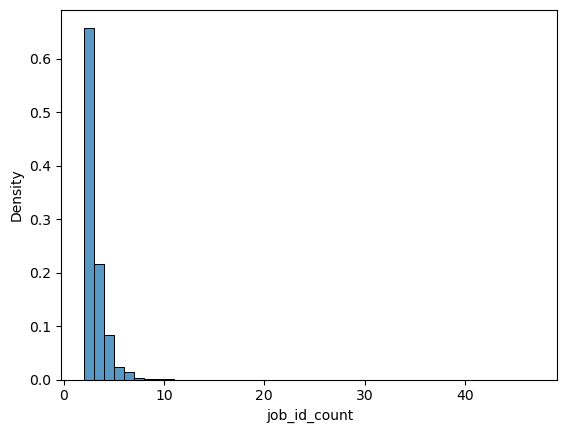

In [16]:
# histogram count of duplicate notes
sns.histplot(data=dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1 ], x="job_id_count", stat='density', binwidth=1);

In [17]:
# dates of duplicates
visitDateDuplicates = mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isin( jobIdWDuplicates ), ['visitDate', 'job_id'] ].copy()
visitDateDuplicates['visitDate'] = pd.to_datetime( visitDateDuplicates['visitDate'], utc=True )
visitDateDuplicates.sort_values(by='visitDate', inplace=True)
visitDateDuplicates.head(5)

,visitDate,job_id
1167123,2000-11-02 00:00:00+00:00,4392495/2229719
416845,2004-02-28 00:00:00+00:00,2891778/923165
1119112,2006-03-28 00:00:00+00:00,2168344/494539
1119115,2006-03-28 00:00:00+00:00,2168344/494539
300174,2006-03-28 00:00:00+00:00,2168405/494608


In [18]:
# how many job_id's have different dates?
dateCount_perID = visitDateDuplicates.groupby(['job_id'])['visitDate'].unique().reset_index(name="unique_dates")
dateCount_perID['n_dates'] = dateCount_perID['unique_dates'].apply( lambda x: len(x) )
dateCount_perID.sort_values(by='n_dates', ascending=False, inplace=True)
dateCount_perID.head(10)

,job_id,unique_dates,n_dates
42594,4168628,"[2020-07-07 00:00:00+00:00, 2020-07-30 00:00:0...",3
31068,3568817,"[2019-06-25 00:00:00+00:00, 2019-06-26 00:00:0...",2
18774,3097983/1070316,"[2008-09-01 00:00:00+00:00, 2008-09-16 00:00:0...",2
59391,4430694,"[2020-12-03 00:00:00+00:00, 2020-12-04 00:00:0...",2
9172,2890728,"[2018-05-15 00:00:00+00:00, 2018-05-16 00:00:0...",2
40265,4092925/1604340,"[2015-01-23 00:00:00+00:00, 2015-07-23 00:00:0...",2
247,2208730,"[2017-03-08 00:00:00+00:00, 2017-07-31 00:00:0...",2
34797,3777638/1642679,"[2010-05-25 00:00:00+00:00, 2010-05-27 00:00:0...",2
60389,4446698,"[2020-12-03 00:00:00+00:00, 2020-12-13 00:00:0...",2
32049,3627794/1215635,"[2014-10-29 00:00:00+00:00, 2015-01-28 00:00:0...",2


In [19]:
print( sum( dateCount_perID['n_dates'] > 1 ) )
print( sum( dateCount_perID['n_dates'] > 1 ) / dateCount_perID.shape[0] )

135
0.002052763628069642


In [20]:
job_id_multiple_dates = list( dateCount_perID.loc[ dateCount_perID['n_dates'] > 1 ]['job_id'].unique() )
print( visitDateDuplicates.loc[ visitDateDuplicates['job_id'].isin( job_id_multiple_dates ) ].shape[0] )
print( visitDateDuplicates.loc[ visitDateDuplicates['job_id'].isin( job_id_multiple_dates ) ].shape[0] / visitDateDuplicates.shape[0] )

311
0.0018641172415859982


In [21]:
visitDateDuplicatesGrp = visitDateDuplicates.groupby(['visitDate']).size().reset_index(name='note_count')
visitDateDuplicatesGrp['cumsum'] = visitDateDuplicatesGrp['note_count'].cumsum()
visitDateDuplicatesGrp['ecdf'] = visitDateDuplicatesGrp['cumsum']/visitDateDuplicatesGrp['note_count'].sum() * pct_duplicates
visitDateDuplicatesGrp

,visitDate,note_count,cumsum,ecdf
0,2000-11-02 00:00:00+00:00,1,1,0.000001
1,2004-02-28 00:00:00+00:00,1,2,0.000002
2,2006-03-28 00:00:00+00:00,8,10,0.000011
3,2006-03-29 00:00:00+00:00,4,14,0.000015
4,2006-03-30 00:00:00+00:00,2,16,0.000017
...,...,...,...,...
2271,2021-01-27 00:00:00+00:00,335,166118,0.174483
2272,2021-01-28 00:00:00+00:00,428,166546,0.174932
2273,2021-01-29 00:00:00+00:00,239,166785,0.175183
2274,2021-01-30 00:00:00+00:00,28,166813,0.175213


/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

Text(0, 0.5, 'cumulative proportion of notes with duplicates')

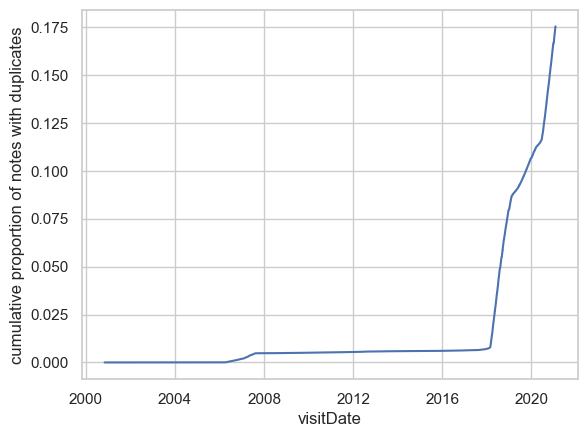

In [23]:
fig, ax = plt.subplots();
sns.set_theme()
sns.set_style("whitegrid")
# need to multiply this by 70%
sns.lineplot(data=visitDateDuplicatesGrp, x="visitDate", y='ecdf', ax=ax);
ax.set_ylabel('cumulative proportion of notes with duplicates')

In [24]:
dfCounts = dfJobIDCount.loc[ dfJobIDCount['job_id'].isin( jobIdWDuplicates ), ['job_id', 'job_id_count'] ].copy()
dfDateThresh = pd.merge( mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isin(jobIdWDuplicates), ['job_id','visitDate'] ], dfCounts , how = 'left', on = 'job_id' )
dfDateThresh['visitDate'] = pd.to_datetime( dfDateThresh['visitDate'], utc=True )
dfDateThresh.sort_values( by = 'visitDate', inplace=True )
dfDateThreshGrp = dfDateThresh.groupby(['visitDate'])['job_id_count'].max().reset_index(name='duplicity')
dfDateThreshGrp['cumulative_duplicity'] = dfDateThreshGrp['duplicity'].cummax()
dfDateThreshGrp['visitDate'] = pd.to_datetime( dfDateThreshGrp['visitDate'], utc=True )
dfDateThreshGrp

,visitDate,duplicity,cumulative_duplicity
0,2000-11-02 00:00:00+00:00,2,2
1,2004-02-28 00:00:00+00:00,2,2
2,2006-03-28 00:00:00+00:00,2,2
3,2006-03-29 00:00:00+00:00,2,2
4,2006-03-30 00:00:00+00:00,2,2
...,...,...,...
2271,2021-01-27 00:00:00+00:00,4,47
2272,2021-01-28 00:00:00+00:00,4,47
2273,2021-01-29 00:00:00+00:00,3,47
2274,2021-01-30 00:00:00+00:00,4,47


/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

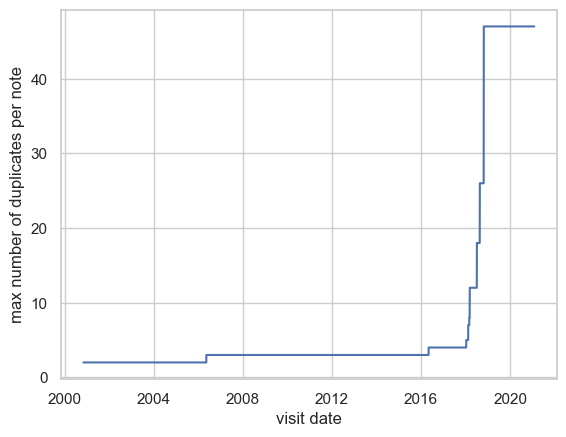

In [25]:
fig, ax = plt.subplots();
sns.set_theme()
sns.set_style("whitegrid")
sns.lineplot(data=dfDateThreshGrp, x="visitDate", y='cumulative_duplicity', ax=ax);
ax.set_ylabel('max number of duplicates per note');
ax.set_xlabel('visit date');

In [26]:
# plot cdf of duplicate notes vs duplicity count
dfDuplicates = dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1, ['job_id', 'job_id_count'] ].copy()
dfGrpByCount = dfDuplicates.groupby(['job_id_count'])['job_id'].size().reset_index(name='number_of_jobIDs')
dfGrpByCount.rename( columns={"job_id_count":"duplicity"}, inplace=True )
dfGrpByCount['total_notes_w_duplicity'] = dfGrpByCount['duplicity'] * dfGrpByCount['number_of_jobIDs']
dfGrpByCount.sort_values(by='duplicity', inplace=True)
dfGrpByCount['ecdf'] = ( dfGrpByCount['total_notes_w_duplicity'].cumsum() / dfGrpByCount['total_notes_w_duplicity'].sum() ) * pct_duplicates
dfGrpByCount

,duplicity,number_of_jobIDs,total_notes_w_duplicity,ecdf
0,2,43271,86542,0.090900
1,3,14238,42714,0.135765
2,4,5495,21980,0.158851
3,5,1561,7805,0.167049
4,6,902,5412,0.172734
5,7,170,1190,0.173984
6,8,87,696,0.174715
7,9,14,126,0.174847
8,10,11,110,0.174963
9,11,1,11,0.174974


/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

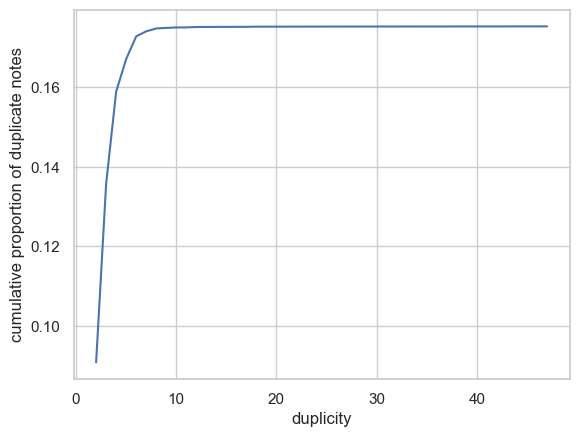

In [27]:
fig, ax = plt.subplots();
sns.set_theme()
sns.set_style("whitegrid")
sns.lineplot(data=dfGrpByCount, x="duplicity", y='ecdf', ax=ax);
ax.set_ylabel('cumulative proportion of duplicate notes');
ax.set_xlabel('duplicity');

# Plot of statistics over selected time frame

In [28]:
# how many notes are between this time period?
startDate='2008-01-01'
endDate='2017-12-31'
maskLowDuplicity=mergedNotesMaster['visitDate'].between( startDate, endDate )
print(f"Proportion of notes between {startDate} and {endDate}: ", sum(maskLowDuplicity)/mergedNotesMaster.shape[0])

Proportion of notes between 2008-01-01 and 2017-12-31:  0.6676057300325674


In [29]:
# how many notes in this period have extractable job id?
nExtractableJob_lowduplicity = mergedNotesMaster.loc[ maskLowDuplicity & mergedNotesMaster['job_id'].notnull() ].shape[0]
print( "Proportion of notes with non-null jobid: ", nExtractableJob_lowduplicity / sum(maskLowDuplicity) )

Proportion of notes with non-null jobid:  0.7536902288675338


In [30]:
# how many notes with extractable job id in this period have duplicates?
pct_duplicates_lowduplicity = mergedNotesMaster.loc[ maskLowDuplicity & mergedNotesMaster['job_id'].isin( jobIdWDuplicates ) ].shape[0] / nExtractableJob_lowduplicity
print( "Proportion of duplicate notes among notes with extractable job id during this period: ",  pct_duplicates_lowduplicity )

Proportion of duplicate notes among notes with extractable job id during this period:  0.003326755259441648


In [31]:
visitDateDuplicates_mask = visitDateDuplicates.loc[ visitDateDuplicates['visitDate'].between(startDate, endDate) ].copy()
visitDateDuplicatesGrp_mask = visitDateDuplicates_mask.groupby(['visitDate']).size().reset_index(name='note_count')
visitDateDuplicatesGrp_mask['cumsum'] = visitDateDuplicatesGrp_mask['note_count'].cumsum()
visitDateDuplicatesGrp_mask['ecdf'] = visitDateDuplicatesGrp_mask['cumsum']/visitDateDuplicatesGrp_mask['note_count'].sum() * pct_duplicates_lowduplicity
visitDateDuplicatesGrp_mask

,visitDate,note_count,cumsum,ecdf
0,2008-01-07 00:00:00+00:00,2,2,0.000003
1,2008-01-17 00:00:00+00:00,2,4,0.000006
2,2008-01-21 00:00:00+00:00,2,6,0.000009
3,2008-02-06 00:00:00+00:00,1,7,0.000011
4,2008-02-07 00:00:00+00:00,1,8,0.000012
...,...,...,...,...
770,2017-12-22 00:00:00+00:00,21,2189,0.003303
771,2017-12-23 00:00:00+00:00,2,2191,0.003306
772,2017-12-24 00:00:00+00:00,3,2194,0.003310
773,2017-12-27 00:00:00+00:00,4,2198,0.003316


/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

Text(0, 0.5, 'cumulative proportion of notes with duplicates')

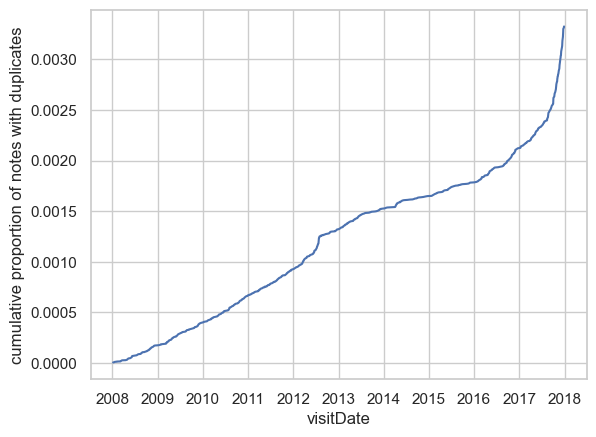

In [32]:
fig, ax = plt.subplots();
sns.set_theme()
sns.set_style("whitegrid")
# need to multiply this by 70%
sns.lineplot(data=visitDateDuplicatesGrp_mask, x="visitDate", y='ecdf', ax=ax);
ax.set_ylabel('cumulative proportion of notes with duplicates')

In [33]:
dfDateThresh_mask = dfDateThresh.loc[ dfDateThresh['visitDate'].between(startDate,endDate) ].copy()
dfDateThreshGrp_mask = dfDateThresh_mask.groupby(['visitDate'])['job_id_count'].max().reset_index(name='duplicity')
dfDateThreshGrp_mask['cumulative_duplicity'] = dfDateThreshGrp_mask['duplicity'].cummax()
dfDateThreshGrp_mask['visitDate'] = pd.to_datetime( dfDateThreshGrp_mask['visitDate'], utc=True )
dfDateThreshGrp_mask

,visitDate,duplicity,cumulative_duplicity
0,2008-01-07 00:00:00+00:00,2,2
1,2008-01-17 00:00:00+00:00,2,2
2,2008-01-21 00:00:00+00:00,2,2
3,2008-02-06 00:00:00+00:00,2,2
4,2008-02-07 00:00:00+00:00,2,2
...,...,...,...
770,2017-12-22 00:00:00+00:00,3,4
771,2017-12-23 00:00:00+00:00,2,4
772,2017-12-24 00:00:00+00:00,2,4
773,2017-12-27 00:00:00+00:00,2,4


/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

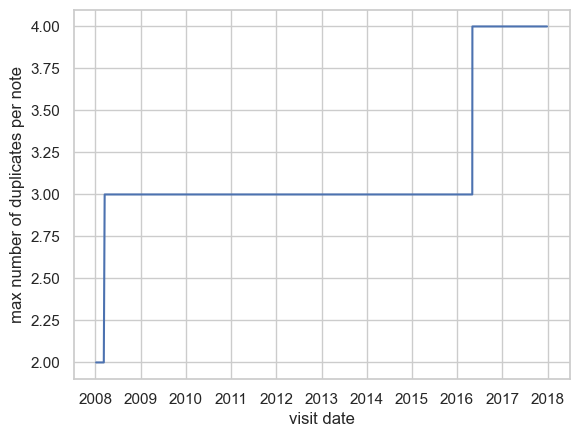

In [34]:
fig, ax = plt.subplots();
sns.set_theme()
sns.set_style("whitegrid")
sns.lineplot(data=dfDateThreshGrp_mask, x="visitDate", y='cumulative_duplicity', ax=ax);
ax.set_ylabel('max number of duplicates per note');
ax.set_xlabel('visit date');

## Investigate status of duplicate notes 

In [35]:
jobId_0817 = list( mergedNotesMaster.loc[ maskLowDuplicity & mergedNotesMaster['job_id'].isin( jobIdWDuplicates ) ]['job_id'].unique() )
print( len(jobId_0817) )

1032


In [36]:
colsToKeep = ['MRN', 'PATIENT_RESEARCH_ID', 'Observations.ProcCode',\
       'Observations.ProcName', 'Observations.Observation._id',\
       'Observations.StatusFromOrder','Observations.Observation.status',\
       'clinical_notes', 'visitDate', 'processed_physician_name', 'job_id', 'lastUpdated' ]
dfDuplicates_0817 = mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isin(jobId_0817), colsToKeep ].copy()
dfDuplicates_0817['status'] = dfDuplicates_0817[['Observations.StatusFromOrder','Observations.Observation.status']].apply(tuple, axis=1)
dfDuplicates_0817.sort_values( by='lastUpdated', ascending=False, inplace=True )

In [37]:
dfDuplicates_0817['lastUpdated']

8363      2021-03-01 20:17:57+00:00
8364      2021-03-01 20:17:35+00:00
502845    2020-10-29 18:23:38+00:00
502846    2020-10-29 18:00:11+00:00
1150379   2020-10-22 13:52:32+00:00
                     ...           
416845    2008-03-10 14:44:28+00:00
199018    2008-02-08 14:49:35+00:00
2758      2008-02-05 23:15:18+00:00
2768      2008-02-04 16:01:19+00:00
792894    2008-02-04 15:28:17+00:00
Name: lastUpdated, Length: 2210, dtype: datetime64[ns, UTC]

In [38]:
dfStatus_0817 = dfDuplicates_0817.groupby(['status']).size().reset_index(name='counts')
dfStatus_0817['count_pct'] = dfStatus_0817['counts']/dfStatus_0817['counts'].sum()
dfStatus_0817.sort_values( by='count_pct', ascending=False, inplace=True )
dfStatus_0817 

,status,counts,count_pct
1,"(completed, dummy)",1307,0.591403
2,"(completed, final)",260,0.117647
8,"(unknown, dummy)",245,0.110860
7,"(dummy, unknown)",158,0.071493
4,"(completed, unknown)",142,0.064253
0,"(completed, corrected)",65,0.029412
9,"(unknown, unknown)",22,0.009955
6,"(draft, preliminary)",9,0.004072
3,"(completed, preliminary)",1,0.000452
5,"(draft, dummy)",1,0.000452


In [37]:
# randomly sample a few job id's and check if the record with the most recent lastUpdated should be the master
saveDir='/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/CheckDuplicates/JobID0817'
random.seed(100)
random_jobid = sample( jobId_0817, 100 )
for job in random_jobid:
    dfTemp = dfDuplicates_0817.loc[ dfDuplicates_0817['job_id'] == job ].copy()
    ptID = dfTemp['PATIENT_RESEARCH_ID'].values[0]
    job_str = job.replace("/","_")
    if not os.path.isdir( f'{saveDir}/{ptID}_{job_str}' ):
        os.mkdir(f'{saveDir}/{ptID}_{job_str}')
    dfTemp.to_csv(f'{saveDir}/{ptID}_{job_str}/record.csv')

In [75]:
sum(dfDuplicates_0817['lastUpdated'].dt.year >= 2019)

92

In [78]:
jobId_recentUpdate = list( dfDuplicates_0817.loc[ dfDuplicates_0817['lastUpdated'].dt.year >= 2019 ]['job_id'].unique() )
saveDir='/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/CheckDuplicates/JobID0817_recentUpdate'
random.seed(100)
random_jobid = sample( jobId_recentUpdate, 25 )
for job in random_jobid:
    dfTemp = dfDuplicates_0817.loc[ dfDuplicates_0817['job_id'] == job ].copy()
    ptID = dfTemp['PATIENT_RESEARCH_ID'].values[0]
    job_str = job.replace("/","_")
    if not os.path.isdir( f'{saveDir}/{ptID}_{job_str}' ):
        os.mkdir(f'{saveDir}/{ptID}_{job_str}')
    dfTemp.to_csv(f'{saveDir}/{ptID}_{job_str}/record.csv')

In [76]:
dfDuplicates_0817

,MRN,PATIENT_RESEARCH_ID,Observations.ProcCode,Observations.ProcName,Observations.Observation._id,Observations.StatusFromOrder,Observations.Observation.status,clinical_notes,visitDate,processed_physician_name,job_id,lastUpdated,status
8363,4288146,SL69266XD.R,4644,Consultation Note,LI75592PR.O,completed,corrected,Date of Visit: 15 Jun 2015\n\nToday I had the...,2015-06-15 00:00:00+00:00,Frances Alice Shepherd,4033372/1544777,2021-03-01 20:17:57+00:00,"(completed, corrected)"
8364,4288146,SL69266XD.R,4644,Consultation Note,VM18210NY.O,completed,corrected,Date of Visit: 15 Jun 2015\n\nToday I had the...,2015-06-15 00:00:00+00:00,Frances Alice Shepherd,4033372/1544777,2021-03-01 20:17:35+00:00,"(completed, corrected)"
502845,2600998,ZB84607IL.R,4644,Consultation Note,MO03814PM.O,completed,corrected,Date of Visit: 06 Dec 2017\n\nWe had the pleas...,2017-12-06 00:00:00+00:00,Abdullah AL Jabri,2639233,2020-10-29 18:23:38+00:00,"(completed, corrected)"
502846,2600998,ZB84607IL.R,4644,Consultation Note,MO88697UR.O,completed,final,Date of Visit: 06 Dec 2017\n\nWe had the pleas...,2017-12-06 00:00:00+00:00,Abdullah AL Jabri,2639233,2020-10-29 18:00:11+00:00,"(completed, final)"
1150379,2964331,AK26043KW.R,5090,Letter,MV13673IS.O,completed,corrected,Date of Visit: 24 Nov 2015\n\nDear Dr. Queresh...,2015-11-25 00:00:00+00:00,Mohammad Shafiee,4279273/1790605,2020-10-22 13:52:32+00:00,"(completed, corrected)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
416845,3224492,CJ19000AK.R,5089,Clinic Note,KY21360MO.O,completed,dummy,Date of Visit: 28Feb2008\n\nMr. Cohen was re-...,2004-02-28 00:00:00+00:00,Gail Darling,2891778/923165,2008-03-10 14:44:28+00:00,"(completed, dummy)"
199018,639029,WG49250DG.R,4652,Radiation Therapy Note,QP42874MU.O,completed,dummy,Date of Visit: 06Feb2008\n\nDear Dr. Fleshner...,2008-02-07 00:00:00+00:00,Ludwik Fedorko,2860165/902863,2008-02-08 14:49:35+00:00,"(completed, dummy)"
2758,2603327,IB30958KZ.R,5089,Clinic Note,WW25325BB.O,completed,dummy,\n\n\nDate of Visit: 17Jan2008\n\nDear Dr. We...,2008-01-17 00:00:00+00:00,Wey-Liang Leong,2838287/899863,2008-02-05 23:15:18+00:00,"(completed, dummy)"
2768,2603327,IB30958KZ.R,5090,Letter,BR50626JS.O,completed,dummy,\n\nDate of Visit: 17Jan2008\n\nDear Dr. Weiz...,2008-01-17 00:00:00+00:00,Wey-Liang Leong,2838287/899863,2008-02-04 16:01:19+00:00,"(completed, dummy)"


# Scratch

In [60]:
saveDir = "/Users/wayne/Desktop/Cluster/ClusterHome"
MRN_num = 4461070
jobid_num = '2516703'
duplicateNotesList = dfDuplicates_0817.loc[ ( dfDuplicates_0817['MRN'] == MRN_num ) & ( dfDuplicates_0817['job_id'] == jobid_num ) ]['clinical_notes'].values
for ctr in range(len(duplicateNotesList)):
    with open(f"{saveDir}/text{ctr}.txt", "w") as file:
        file.write(duplicateNotesList[ctr])

In [51]:
duplicateNotesList

array(['Date of Visit: 28 Sep 2017\n\nDear Dr. Berger:\n\nThank you for referring Ms. Yvonne Fleming to the Department of Psychosocial Oncology for psychiatric care. She was referred for assessment of depression and counseling to support coping with cancer.\n\nAs you are aware, Yvonne is a 79-year-old, married woman currently living in the Lawrence and Yonge area of Toronto with her son, Jonathan. Yvonne reported today that her husband, Sanford, was placed in long-term care around April of this year due to symptoms of Alzheimer\'s. She notes that she is financially supported through savings and denies any current financial concerns. She has had some contact with psychiatry in the 1980s when seeing a psychoanalyst and started seeing Dr. Adrian Grek approximately 10 years ago, reconnecting with him around January of this year and seeing him on approximately 4 occasions, last seen 3 months ago. She notes a past history of depression.\n\nYvonne was seen with her son, Jonathan, in the Depar

In [41]:
txt1 = dfDuplicates_0817.loc[ dfDuplicates_0817['MRN'] == 805878 ]['clinical_notes'].values[0]
txt2 = dfDuplicates_0817.loc[ dfDuplicates_0817['MRN'] == 805878 ]['clinical_notes'].values[1]

In [42]:
txt1

"\nPROCEDURE: Left carotid micro endarterectomy with microscope and Evoked \npotential monitoring. \n\nDATE OF PROCEDURE: December 12, 2017. \nSURGEON: Dr. Michael Tymianski. \nASSISTANT: \nANESTHETIST: \nANESTHESIA: General. \n\nPREOPERATIVE DIAGNOSIS: Left carotid stenosis with TIAs. \n\nPOSTOPERATIVE DIAGNOSIS: Left carotid stenosis with TIAs. \n\nCLINICAL NOTE: This patient had several TIAs. He was readmitted to hospital \nhaving TIAs and was put on HEPARIN and was booked semi-emergently. \n\nOPERATIVE NOTE: With the patient with a HEPARIN drip running and under general \nanesthesia, the left side of the neck was positioned, marked, prepped, and \ndraped as per a left carotid endarterectomy. Despite the fact that the patient \nwas heparinized, we did a routine approach to the internal carotid artery \nwithout any difficulty. The common internal and external were exposed. The \ninternal carotid was then cross clamped after the patient was given an \nadditional 3000 units of HEPARIN 

In [43]:
txt2

"PROCEDURE:  Left carotid micro endarterectomy with microscope and Evoked potential monitoring.\n \nDATE OF PROCEDURE:  December 12, 2017.\nSURGEON:  Dr. Michael Tymianski.\nASSISTANT:  \nANESTHETIST:  \nANESTHESIA: General.\n \nPREOPERATIVE DIAGNOSIS:  Left carotid stenosis with TIAs.\n \nPOSTOPERATIVE DIAGNOSIS:  Left carotid stenosis with TIAs.\n \nCLINICAL NOTE:  This patient had several TIAs.  He was readmitted to hospital having TIAs and was put on HEPARIN and was booked semi-emergently.\n \nOPERATIVE NOTE:  With the patient with a HEPARIN drip running and under general anesthesia, the left side of the neck was positioned, marked, prepped, and draped as per a left carotid endarterectomy.  Despite the fact that the patient was heparinized, we did a routine approach to the internal carotid artery without any difficulty.  The common internal and external were exposed.  The internal carotid was then cross clamped after the patient was given an additional 3000 units of HEPARIN followe

In [56]:
temp = dfDuplicates_0817.groupby(['job_id'])['status'].unique().reset_index(name='all_status')
temp['len_status'] = temp['all_status'].apply(lambda x: len(x))
temp.sort_values(by='len_status', ascending=False, inplace=True)
temp.head(10)

,job_id,all_status,len_status
128,2179437,"[(draft, preliminary), (unknown, dummy), (comp...",4
454,2657931,"[(completed, dummy), (completed, final), (comp...",4
442,2651767,"[(completed, preliminary), (completed, final),...",4
436,2646453,"[(completed, dummy), (completed, final), (comp...",3
451,2656954,"[(completed, dummy), (completed, final), (comp...",3
449,2656487,"[(completed, unknown), (completed, final), (co...",3
210,2402371,"[(completed, dummy), (completed, final), (comp...",3
445,2654326,"[(completed, dummy), (completed, unknown), (co...",3
444,2653873,"[(completed, unknown), (completed, final), (co...",3
443,2653774,"[(completed, dummy), (completed, final), (comp...",3


In [58]:
print(temp.shape[0])
print(temp.loc[ temp.len_status >= 3 ].shape[0])

1032
128


In [2]:
dataDir = '/Users/wayne/Desktop/Cluster/H4Hhome/2BLAST/clinical_notes/HealthReportRecords/results_status_dates/processed/dataframes'
tempp = pd.read_csv(f'{dataDir}/processedClinicalNotes_{0}.csv')

In [51]:
tempp['lastUpdated']

0       2018-06-07T16:30:00Z
1       2016-11-22T14:07:16Z
2       2018-06-07T16:30:00Z
3       2019-12-19T23:08:00Z
4       2016-07-01T00:26:17Z
                ...         
2261    2013-07-16T05:47:01Z
2262    2013-09-21T05:04:11Z
2263    2013-09-20T05:00:24Z
2264    2013-09-11T00:57:50Z
2265    2013-09-11T00:27:30Z
Name: lastUpdated, Length: 2266, dtype: object

In [61]:
tempp['lastUpdated_strip'] = tempp['lastUpdated'].apply( lambda x: x.replace('T', ' ').replace('Z','')[:19] )

In [62]:
tempp['lastUpdated_strip']

0       2018-06-07 16:30:00
1       2016-11-22 14:07:16
2       2018-06-07 16:30:00
3       2019-12-19 23:08:00
4       2016-07-01 00:26:17
               ...         
2261    2013-07-16 05:47:01
2262    2013-09-21 05:04:11
2263    2013-09-20 05:00:24
2264    2013-09-11 00:57:50
2265    2013-09-11 00:27:30
Name: lastUpdated_strip, Length: 2266, dtype: object

In [63]:
tempp['str_len'] = tempp['lastUpdated_strip'].apply(lambda x: len(x))
print( tempp['str_len'].max() )
print( tempp['str_len'].min() )

19
19


In [60]:
tempp.loc[ tempp['str_len'] == 29 ]

,Unnamed: 0,MRN,PATIENT_RESEARCH_ID,Observations.ProcCode,Observations.ProcName,Observations.Observation._id,Observations.StatusFromOrder,Observations.OccurrenceDateTimeFromOrder,Observations.Observation.basedOn.0.reference,Observations.Observation.encounter.reference,...,report_type,specialty,transcribed_by,clinical_notes,visitDate,physician_name,processed_physician_name,lastUpdated,lastUpdated_strip,str_len
20,20,46558,TW53882LK.R,5089,Clinic Note,BK76272OP.O,draft,2020-12-11 08:34:00+00:00,AQ89033IC.R,HR90185KM.E,...,Clinic Note,Radiation Oncology,Uhn EDoc-Interface,Date of Visit: 10 Dec 2020\n\nI spoke to Ms. ...,2020-12-10,"David Benjamin Shultz, MD",David Benjamin Shultz,2020-12-11T13:34:19.167003021Z,2020-12-11 13:34:19.167003021,29
23,23,46558,TW53882LK.R,5089,Clinic Note,CG69404XS.O,draft,2020-12-11 08:34:00+00:00,YF74717LY.R,HR90185KM.E,...,Clinic Note,Radiation Oncology,Uhn EDoc-Interface,Date of Visit: 10 Dec 2020\n\nI spoke to Ms. ...,2020-12-10,"David Benjamin Shultz, MD",David Benjamin Shultz,2020-12-11T21:15:46.882165327Z,2020-12-11 21:15:46.882165327,29
33,33,46558,TW53882LK.R,5089,Clinic Note,EZ46925YW.O,completed,2020-09-11 07:41:00+00:00,QU10093GQ.R,IZ67540LJ.E,...,Clinic Note,Hematology/Oncology,Uhn EDoc-Interface,Date of Visit: 09 Sep 2020\n\nAn 80-year-old f...,2020-09-10,"Geoffrey Liu, MD",Geoffrey Liu,2020-09-23T12:09:29.695862035Z,2020-09-23 12:09:29.695862035,29
46,46,46558,TW53882LK.R,5089,Clinic Note,JL79998SK.O,completed,2021-01-29 13:52:00+00:00,EZ97686BZ.R,CE46266MW.E,...,Clinic Note,Neurosurgery,Uhn EDoc-Interface,Date of Visit: 29 Jan 2021\n\nI had the pleas...,2021-01-29,"Paul Narin Kongkham, MD",Paul Narin Kongkham,2021-01-31T20:41:05.473686053Z,2021-01-31 20:41:05.473686053,29
48,48,46558,TW53882LK.R,5089,Clinic Note,KE95740RF.O,completed,2020-09-11 07:41:00+00:00,RW32373RQ.R,IZ67540LJ.E,...,Clinic Note,Hematology/Oncology,Uhn EDoc-Interface,Date of Visit: 09 Sep 2020\n\nAn 80-year-old f...,2020-09-10,"Geoffrey Liu, MD",Geoffrey Liu,2020-09-23T12:09:46.341888431Z,2020-09-23 12:09:46.341888431,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,2235,4698406,DL18256JU.R,5089,Clinic Note,BE64891AY.O,completed,2020-10-24 07:35:00+00:00,LO32491EM.R,QF74615WE.E,...,Clinic Note,General Surgery,Uhn EDoc-Interface,Date of Visit: 22 Oct 2020\n\nI had the pleasu...,2020-10-23,"Ian Douglas. McGilvray, MD",Ian Douglas McGilvray,2021-01-26T14:40:11.356089894Z,2021-01-26 14:40:11.356089894,29
2236,2236,4698406,DL18256JU.R,5089,Clinic Note,HO41869SI.O,completed,2020-12-18 14:20:00+00:00,JA64445MR.R,II06163HC.E,...,Clinic Note,General Surgery,Uhn EDoc-Interface,Date of Visit: 17 Dec 2020\n\nI spoke to Mr. ...,2020-12-18,"Ian Douglas. McGilvray, MD",Ian Douglas McGilvray,2020-12-18T19:20:31.183379952Z,2020-12-18 19:20:31.183379952,29
2240,2240,6024599,UQ16991VC.R,4644,Consultation Note,QD78179JM.O,completed,2020-09-23 17:17:00+00:00,DS40864DJ.R,NM22022BS.E,...,Consultation Note,General Internal Medicine,Uhn EDoc-Interface,Date of Visit: 23 Sep 2020\n\nTIME:\n10 a.m. t...,2020-09-23,"Barry J. Goldlist, MD",Barry Goldlist,2020-09-25T20:13:36.848144358Z,2020-09-25 20:13:36.848144358,29
2241,2241,6024599,UQ16991VC.R,4644,Consultation Note,XL18724AT.O,draft,2020-09-23 17:17:00+00:00,KZ00967GY.R,NM22022BS.E,...,Consultation Note,General Internal Medicine,Uhn EDoc-Interface,Date of Visit: 23 Sep 2020\n\nTIME: \n10 a.m...,2020-09-23,"Barry J. Goldlist, MD",Barry Goldlist,2020-09-23T21:17:20.744492771Z,2020-09-23 21:17:20.744492771,29


In [8]:
tempp['lastUpdated_strip'] = pd.to_datetime( tempp['lastUpdated'].apply( lambda x: x[:10] ), utc=True )
tempp['lastUpdated_strip']

0      2018-06-07 00:00:00+00:00
1      2016-11-22 00:00:00+00:00
2      2018-06-07 00:00:00+00:00
3      2019-12-19 00:00:00+00:00
4      2016-07-01 00:00:00+00:00
                  ...           
2261   2013-07-16 00:00:00+00:00
2262   2013-09-21 00:00:00+00:00
2263   2013-09-20 00:00:00+00:00
2264   2013-09-11 00:00:00+00:00
2265   2013-09-11 00:00:00+00:00
Name: lastUpdated_strip, Length: 2266, dtype: datetime64[ns, UTC]

In [64]:
tempp['lastUpdated_strip'] = pd.to_datetime( tempp['lastUpdated_strip'], utc=True,format='%Y-%m-%d %H:%M:%S' )

In [65]:
tempp['lastUpdated_strip']

0      2018-06-07 16:30:00+00:00
1      2016-11-22 14:07:16+00:00
2      2018-06-07 16:30:00+00:00
3      2019-12-19 23:08:00+00:00
4      2016-07-01 00:26:17+00:00
                  ...           
2261   2013-07-16 05:47:01+00:00
2262   2013-09-21 05:04:11+00:00
2263   2013-09-20 05:00:24+00:00
2264   2013-09-11 00:57:50+00:00
2265   2013-09-11 00:27:30+00:00
Name: lastUpdated_strip, Length: 2266, dtype: datetime64[ns, UTC]

In [3]:
tempp['lastUpdated'] = pd.to_datetime( tempp['lastUpdated'], utc=True )

ValueError: time data "2020-12-11T13:34:19.167003021Z" doesn't match format "%Y-%m-%dT%H:%M:%S%z", at position 20. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [53]:
mergedNotesMaster.loc[ mergedNotesMaster['job_id'] == '933311/352090' ]

,MRN,PATIENT_RESEARCH_ID,Observations.ProcCode,Observations.ProcName,Observations.Observation._id,Observations.StatusFromOrder,Observations.OccurrenceDateTimeFromOrder,Observations.Observation.basedOn.0.reference,Observations.Observation.encounter.reference,Observations.Observation.status,...,transcribed_by,clinical_notes,visitDate,physician_name,processed_physician_name,attending_staff_signing_off_note,dictating_md_verifying_note,dictated_by_and_or_verified_by_resident_s_attending,dictated_by_for,job_id
204377,3287967,UP10008LY.R,5089,Clinic Note,UU13338SB.O,completed,2013-02-04 00:00:00+00:00,TF95066GW.R,QT70525CO.E,dummy,...,None,Date of Visit: 04 Feb 2013\n\n\nDIAGNOSIS: T...,2013-02-04,Dr. Natasha Basant Leighl,Natasha Basant Leighl,None,None,None,None,933311/352090
700731,416955,GQ60563MF.R,5089,Clinic Note,MI86724ES.O,completed,2013-02-04 10:41:00+00:00,OG87100HE.R,LJ67761JY.E,dummy,...,June Pevere,Date of Visit: 04 Feb 2013\n\n\n\nDIAGNOSIS: ...,2013-02-04,Dr. Natasha Basant Leighl,Natasha Basant Leighl,None,None,None,None,933311/352090


In [ ]:
# check max duplicity

In [44]:
jobId_0817

['200600/49018',
 '4432298/2298732',
 '4461755/2292497',
 '2381602',
 '2838287/899863',
 '234645/67870',
 '1168477/412927',
 '4694140/2205300',
 '2454497',
 '3570554/1462152',
 '4522501/2033750',
 '197099/47187',
 '2665185',
 '4033372/1544777',
 '2244531',
 '3756292/1646540correctedcopyby:spm3756292/1629929',
 '2009576',
 '2544595',
 '3430414/1138057',
 '4628503/2501288',
 '3873073/1730422',
 '1090397/392484',
 '2635045',
 '3417230/1331371',
 '3751713/1620045',
 '2313937',
 '1228403/428532',
 '3767766/1640430',
 '3231099/1175709',
 '2665056',
 '2533568',
 '4266996/2131274',
 '2531326',
 '3797414/1663409',
 '4406388/1917663',
 '2035589',
 '3337521/1263480',
 '2454849',
 '177305/35496',
 '2550020',
 '3185716/1138909',
 '2669298',
 '4593394/2458306',
 '1356038/460986',
 '2529100',
 '2615898',
 '4077717/1937416',
 '3851580/1711332',
 '3653468/1532972',
 '488510/204261',
 '4422967/1934245',
 '4695741/2206900',
 '3853052/1713555',
 '2063234',
 '2421831',
 '2410478',
 '2602645',
 '2434132',
 

## Old format of job id

In [56]:
# investigate those with one slash only
# check what the dates are
dfJobIDSlash = dfJobIDCount.loc[ (dfJobIDCount['count_slash'] == 1) & (~dfJobIDCount['has_char']) ].copy()
dfJobIDSlash[['job_id_part1','job_id_part2']] = dfJobIDSlash['job_id'].str.split('/', expand=True)


In [57]:
dfJobIDSlash

,job_id,job_id_count,has_char,job_id_len,has_dash,count_slash,job_id_part1,job_id_part2
772901,4514394/2025633,4,False,15,0,1,4514394,2025633
783605,4545334/2056560,3,False,15,0,1,4545334,2056560
732269,4422221/1933494,3,False,15,0,1,4422221,1933494
156717,2482892/674565,3,False,14,0,1,2482892,674565
827390,4731182/2242354,3,False,15,0,1,4731182,2242354
...,...,...,...,...,...,...,...,...
285578,2956860/969241,1,False,14,0,1,2956860,969241
285579,2956867/969658,1,False,14,0,1,2956867,969658
285580,2956871/969660,1,False,14,0,1,2956871,969660
285581,2956879/962546,1,False,14,0,1,2956879,962546


In [59]:
# try splitting and seeing if there are duplicates in the split job id's
# dfJobIDSlash['job_id_part1'] = dfJobIDSlash['job_id_part1'].astype(int)
# dfJobIDSlash['job_id_part2'] = dfJobIDSlash['job_id_part2'].astype(int)

In [66]:
# group by job_id_part1
dfJobIDPart1Size = dfJobIDSlash.groupby(['job_id_part1']).size().reset_index(name='counts')
dfJobIDPart1Size.sort_values(by='counts',ascending=False,inplace=True)
dfJobIDPart1Size.head()

,job_id_part1,counts
1,0,167
0,,5
383143,4057345,4
358242,3967437,3
328542,3856460,3


In [67]:
dfJobIDPart2Size = dfJobIDSlash.groupby(['job_id_part2']).size().reset_index(name='counts')
dfJobIDPart2Size.sort_values(by='counts',ascending=False,inplace=True)
dfJobIDPart2Size.head()

,job_id_part2,counts
0,,14
491425,723162,5
342686,2202298,4
342244,2200829,4
39754,1137650,3


In [83]:
# count how many unique job_id
part1_id = list( dfJobIDPart1Size.loc[ dfJobIDPart1Size['counts'] > 1 ]['job_id_part1'].unique() )
df_duplicate_part1 = dfJobIDSlash.loc[ dfJobIDSlash['job_id_part1'].isin( part1_id ) ].copy()
# group by job_id_part1 and find the number of unique job_id
df_duplicate_part1_grp = df_duplicate_part1.groupby(['job_id_part1'])['job_id'].unique().reset_index(name='unique_job_id')
df_duplicate_part1_grp['len_unique_job_id'] = df_duplicate_part1_grp['unique_job_id'].apply( lambda x: len(x) )
# try to match the number of counts
map_jobidpart1_counts = dict( zip( dfJobIDPart1Size['job_id_part1'], dfJobIDPart1Size['counts'] ) )
df_duplicate_part1_grp['mapped_counts'] = df_duplicate_part1_grp['job_id_part1'].map( map_jobidpart1_counts )

In [85]:
df_duplicate_part1_grp.loc[ df_duplicate_part1_grp['len_unique_job_id'] != df_duplicate_part1_grp['mapped_counts'] ]

,job_id_part1,unique_job_id,len_unique_job_id,mapped_counts


In [81]:
sum( df_duplicate_part1_grp['len_unique_job_id'] == 1 )

0

In [68]:
sum( dfJobIDPart1Size['counts'] > 1 )

27887

In [69]:
dfJobIDPart1Size['counts'].shape[0]

582112